# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [1]:
from __future__ import annotations

import torch
from torch import nn

## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.


In [2]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
            nn.init.zeros_(self.bias)
        else:
            self.bias = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        y = x @ self.weight.T
        if self.bias is not None:
            y += self.bias
        return y

In [3]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.weight = nn.Parameter(torch.empty(num_embeddings, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        
    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        return self.weight[idx]

In [4]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        
        if self.training:
            mask = (torch.rand_like(x) > p).float() / (1 - p)
            return x * mask
        else:
            return x

## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [59]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.elementwise_affine = elementwise_affine
        if elementwise_affine:
            self.weight = nn.Parameter(torch.ones(normalized_shape))
            self.bias = nn.Parameter(torch.zeros(normalized_shape))
        else:
            self.weight = None
            self.bias = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_normalized = (x - mean) / torch.sqrt(var + self.eps)
        if self.elementwise_affine:
            x_normalized = x_normalized * self.weight + self.bias
        return x_normalized

In [7]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(normalized_shape))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_normalized = x / torch.sqrt(mean(x**2) + self.eps) * self.weight
        return x_normalized

## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [60]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()
        self.net = nn.Sequential(
            Linear(in_dim, hidden_dim),
            nn.ReLU(),
            *(
                [LayerNorm(hidden_dim)] if use_layernorm else []
            ),
            *(
                [Linear(hidden_dim, hidden_dim), nn.ReLU()] * (depth - 1)
            ),
            Linear(hidden_dim, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [9]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.net = nn.Sequential(
            Linear(d_model, d_ff),
            nn.GELU(),
            Linear(d_ff, d_model),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [10]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        self.fn = fn

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        return x + self.fn(x, ...)


## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [11]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [16]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

In [13]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
    loss = -log_probs[torch.arange(logits.size(0)), targets].mean()
    return loss

In [14]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        self.d_in = d_in
        self.num_classes = num_classes
        self.linear = Linear(d_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        return self.linear(x)

In [52]:
def accuracy(loader, model):
    correct = 0
    total = 0
    for x, y in loader:
        logits = model(x.flatten(start_dim = 1, end_dim = 3))
        pred = logits.argmax(dim=-1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total

In [56]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    model.train()
    for epoch in range(epochs):
        for batch in train_data_loader:
            x, y = batch
            x, y = x.flatten(start_dim = 1, end_dim = 3), y
            optimizer.zero_grad()
            logits = model(x)
            loss = cross_entropy_from_logits(logits, y)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            train_losses.append(loss.item())
        print(f"Epoch {epoch}, loss {torch.Tensor(train_losses).mean():.4f}")
        model.eval()
        acc = accuracy(test_data_loader, model)
        print(f"Test accuracy: {acc:.4f}")
        model.train()
    return train_losses


In [54]:
train_losses = train_classifier(
    model=ClassificationHead(d_in=784, num_classes=10),
    train_data_loader=train_loader,  
    test_data_loader=test_loader,
    lr=1e-3,
    epochs=9,
)

Epoch 0, loss 0.5617
Test accuracy: 0.9116
Epoch 1, loss 0.4437
Test accuracy: 0.9163
Epoch 2, loss 0.3946
Test accuracy: 0.9217
Epoch 3, loss 0.3666
Test accuracy: 0.9218
Epoch 4, loss 0.3481
Test accuracy: 0.9256
Epoch 5, loss 0.3348
Test accuracy: 0.9248
Epoch 6, loss 0.3247
Test accuracy: 0.9259
Epoch 7, loss 0.3166
Test accuracy: 0.9266
Epoch 8, loss 0.3100
Test accuracy: 0.9278


Text(0, 0.5, 'Training Loss')

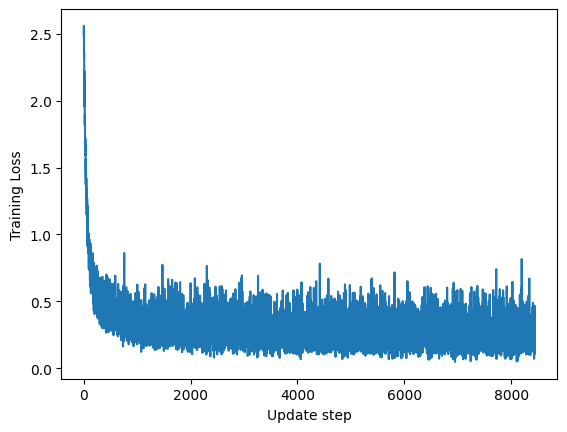

In [55]:
import matplotlib.pyplot as plt
plt.plot(train_losses)
plt.xlabel("Update step")
plt.ylabel("Training Loss")

In [62]:
train_losses = train_classifier(
    model= nn.Sequential(MLP(in_dim=784, hidden_dim = 128, out_dim=784, depth = 2, use_layernorm=True), ClassificationHead(d_in=784, num_classes=10)),
    train_data_loader=train_loader,  
    test_data_loader=test_loader,
    lr=1e-3,
    epochs=9,
)

Epoch 0, loss 0.2148
Test accuracy: 0.9645
Epoch 1, loss 0.1589
Test accuracy: 0.9669
Epoch 2, loss 0.1309
Test accuracy: 0.9670
Epoch 3, loss 0.1134
Test accuracy: 0.9735
Epoch 4, loss 0.1014
Test accuracy: 0.9761
Epoch 5, loss 0.0918
Test accuracy: 0.9676
Epoch 6, loss 0.0844
Test accuracy: 0.9694
Epoch 7, loss 0.0781
Test accuracy: 0.9759
Epoch 8, loss 0.0732
Test accuracy: 0.9723


Text(0, 0.5, 'Training Loss')

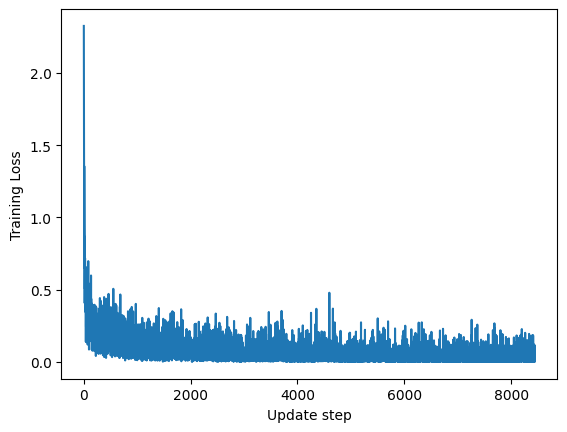

In [63]:
import matplotlib.pyplot as plt
plt.plot(train_losses)
plt.xlabel("Update step")
plt.ylabel("Training Loss")